# Exploratory Data Analysis

This notebook examines dataset size, label balance, missingness, observed feature values, and train/test missingness consistency. It uses the full supplied training and test datasets. Feature indices are zero-based and exclude the CSV Id column; the helper returns Id separately.

The analysis is descriptive. It motivates preprocessing experiments but does not establish which choices improve validation performance. Missingness refers to NaN values produced by the CSV loader; encoded special responses require separate checks against field definitions.


In [1]:
import csv
import numpy as np

from helpers import load_csv_data

# Run this notebook from the P1 directory.
x_train, x_test, y_train, train_ids, test_ids = load_csv_data("data/dataset")
with open("data/dataset/x_train.csv", newline="") as f:
    feature_names = next(csv.reader(f))[1:]


In [2]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("train_ids shape:", train_ids.shape)
print("test_ids shape:", test_ids.shape)

x_train shape: (328135, 321)
y_train shape: (328135,)
x_test shape: (109379, 321)
train_ids shape: (328135,)
test_ids shape: (109379,)


In [3]:
labels, counts = np.unique(y_train, return_counts=True)

print("Labels:", labels)
print("Counts:", counts)
print("Proportions:", counts / len(y_train))

Labels: [-1  1]
Counts: [299160  28975]
Proportions: [0.91169793 0.08830207]


## Label Balance

The training set contains 299,160 negative labels (-1; 91.17%) and 28,975 positive labels (+1; 8.83%). An always-negative classifier achieves 91.17% accuracy but zero positive-class recall and F1. Accuracy alone is therefore insufficient; report positive-class precision, recall, and F1 as well, and preserve class proportions with stratified validation splits.


## Missingness Overview

The training matrix contains 47,175,779 NaN entries (44.79% of all feature values). Of 321 features, 239 contain missing values, 147 are more than 50% missing, and 99 are more than 90% missing; none is entirely missing. Each training sample has between 80 and 218 missing features, with a median of 139.

These results motivate comparing imputation, missingness indicators, and feature removal using validation. High missingness alone does not establish that a feature is uninformative. The following summaries count NaN values only.


In [4]:
print("NaN count:", np.isnan(x_train).sum())
print("Inf count:", np.isinf(x_train).sum())

print("Global min:", np.nanmin(x_train))
print("Global max:", np.nanmax(x_train))

NaN count: 47175779
Inf count: 0
Global min: 0.0
Global max: 2015023235.0


In [5]:
missing_count = np.isnan(x_train).sum(axis=0)
missing_rate = missing_count / x_train.shape[0]

print("Features with no missing values:",
      np.sum(missing_rate == 0))

print("Features with missing values:",
      np.sum(missing_rate > 0))

print("Features with >50% missing:",
      np.sum(missing_rate > 0.5))

print("Features with >90% missing:",
      np.sum(missing_rate > 0.9))

print("Features with 100% missing:",
      np.sum(missing_rate == 1))

Features with no missing values: 82
Features with missing values: 239
Features with >50% missing: 147
Features with >90% missing: 99
Features with 100% missing: 0


In [6]:
top_missing = np.argsort(missing_rate)[::-1][:20]

for j in top_missing:
    print(
        f"Feature {j:3d} ({feature_names[j]}): "
        f"{missing_rate[j]:.2%} missing "
        f"({missing_count[j]} values)"
    )

Feature  14 (LADULT): 99.99% missing (328103 values)
Feature  11 (COLGHOUS): 99.99% missing (328103 values)
Feature 191 (PCDMDECN): 99.95% missing (327956 values)
Feature 148 (ASDRVIST): 99.93% missing (327907 values)
Feature 147 (ASERVIST): 99.93% missing (327907 values)
Feature 152 (ASNOSLEP): 99.90% missing (327793 values)
Feature 154 (ASINHALR): 99.85% missing (327650 values)
Feature 153 (ASTHMED3): 99.85% missing (327650 values)
Feature 151 (ASYMPTOM): 99.85% missing (327649 values)
Feature 150 (ASACTLIM): 99.85% missing (327648 values)
Feature 149 (ASRCHKUP): 99.85% missing (327648 values)
Feature 146 (ASATTACK): 99.85% missing (327645 values)
Feature 156 (STREHAB1): 99.84% missing (327618 values)
Feature 190 (PCPSADE1): 99.82% missing (327539 values)
Feature 155 (HAREHAB1): 99.76% missing (327362 values)
Feature 145 (ASTHMAGE): 99.76% missing (327354 values)
Feature 130 (VINOCRE2): 99.76% missing (327339 values)
Feature  22 (CCLGHOUS): 99.76% missing (327334 values)
Feature 168 

In [7]:
print("Missing-rate distribution:")

print("0%       :", np.sum(missing_rate == 0))
print("(0,10%]  :", np.sum((missing_rate > 0) & (missing_rate <= 0.1)))
print("(10,50%] :", np.sum((missing_rate > 0.1) & (missing_rate <= 0.5)))
print("(50,90%] :", np.sum((missing_rate > 0.5) & (missing_rate <= 0.9)))
print("(90,100%]:", np.sum((missing_rate > 0.9) & (missing_rate <= 1)))

Missing-rate distribution:
0%       : 82
(0,10%]  : 57
(10,50%] : 35
(50,90%] : 48
(90,100%]: 99


In [8]:
missing_per_row = np.isnan(x_train).sum(axis=1)

print("Missing features per sample:")
print("Min   :", np.min(missing_per_row))
print("Median:", np.median(missing_per_row))
print("Mean  :", np.mean(missing_per_row))
print("Max   :", np.max(missing_per_row))

Missing features per sample:
Min   : 80
Median: 139.0
Mean  : 143.76942112240388
Max   : 218


In [9]:
missing_neg = missing_per_row[y_train == -1]
missing_pos = missing_per_row[y_train == 1]

print("y = -1:")
print("  Mean missing   :", np.mean(missing_neg))
print("  Median missing :", np.median(missing_neg))

print("\ny = +1:")
print("  Mean missing   :", np.mean(missing_pos))
print("  Median missing :", np.median(missing_pos))

y = -1:
  Mean missing   : 143.97685519454473
  Median missing : 140.0

y = +1:
  Mean missing   : 141.6277135461605
  Median missing : 138.0


In [10]:
missing_rate_neg = np.isnan(x_train[y_train == -1]).mean(axis=0)
missing_rate_pos = np.isnan(x_train[y_train == 1]).mean(axis=0)

missing_rate_diff = np.abs(missing_rate_pos - missing_rate_neg)

top_diff = np.argsort(missing_rate_diff)[::-1][:20]

for j in top_diff:
    print(
        f"Feature {j:3d} ({feature_names[j]}): "
        f"-1 missing={missing_rate_neg[j]:.2%}, "
        f"+1 missing={missing_rate_pos[j]:.2%}, "
        f"diff={100 * missing_rate_diff[j]:.2f} percentage points"
    )

Feature  35 (BPMEDS): -1 missing=63.14%, +1 missing=25.69%, diff=37.45 percentage points
Feature 318 (_FLSHOT6): -1 missing=67.38%, +1 missing=33.84%, diff=33.54 percentage points
Feature 319 (_PNEUMO2): -1 missing=67.38%, +1 missing=33.84%, diff=33.54 percentage points
Feature  95 (LMTJOIN3): -1 missing=71.41%, +1 missing=45.81%, diff=25.60 percentage points
Feature  96 (ARTHDIS2): -1 missing=71.45%, +1 missing=45.89%, diff=25.56 percentage points
Feature  97 (ARTHSOCL): -1 missing=71.49%, +1 missing=46.00%, diff=25.49 percentage points
Feature  98 (JOINPAIN): -1 missing=72.03%, +1 missing=46.96%, diff=25.07 percentage points
Feature  49 (DIABAGE2): -1 missing=89.01%, +1 missing=67.75%, diff=21.26 percentage points
Feature  73 (SMOKDAY2): -1 missing=59.96%, +1 missing=41.39%, diff=18.57 percentage points
Feature  75 (LASTSMK2): -1 missing=73.76%, +1 missing=57.68%, diff=16.08 percentage points
Feature  29 (POORHLTH): -1 missing=50.11%, +1 missing=34.38%, diff=15.72 percentage points
F

### Missingness and the Target

Total missingness per sample is similar across classes (means of 143.98 for -1 and 141.63 for +1), but some individual features show much larger differences. For example, BPMEDS (feature 35) is missing in 63.14% of negative samples and 25.69% of positive samples, a difference of 37.45 percentage points.

This association motivates testing missingness indicators. It does not establish causality or guarantee predictive improvement; survey routing or other data-collection rules may contribute to the pattern and require field-level interpretation.


## Feature Statistics and Scale

Feature-level statistics below exclude NaN values. Six features have zero variance among observed values (indices 9, 11, 12, 18, 19, and 22), but all six contain missing values. Their missingness patterns may still carry predictive information. Removing constant observed values while retaining missingness indicators should be evaluated separately from dropping the columns entirely.

Observed standard deviations vary widely, motivating scaling for magnitude-sensitive models. However, large values do not necessarily represent large continuous measurements: feature 2 is IDATE, and features 7 and 8 are SEQNO and _PSU. Their field definitions should be checked before deciding whether to transform, encode, retain, or remove them. Large values alone do not establish the presence of outliers.


In [11]:
valid_count = np.sum(~np.isnan(x_train), axis=0)

feature_mean = np.nanmean(x_train, axis=0)
feature_std = np.nanstd(x_train, axis=0)
feature_min = np.nanmin(x_train, axis=0)
feature_max = np.nanmax(x_train, axis=0)

constant_features = np.where(feature_std == 0)[0]

print("Constant features:", len(constant_features))
print("Indices:", constant_features)

print("\nFeature value ranges:")
print("Smallest finite value:", np.nanmin(x_train))
print("Largest finite value :", np.nanmax(x_train))

print("\nFeature std:")
print("Min non-zero std:", np.min(feature_std[feature_std > 0]))
print("Median std      :", np.median(feature_std))
print("Max std         :", np.max(feature_std))

Constant features: 6
Indices: [ 9 11 12 18 19 22]

Feature value ranges:
Smallest finite value: 0.0
Largest finite value : 2015023235.0

Feature std:
Min non-zero std: 0.010901348287924363
Median std      : 1.366028477462242
Max std         : 3489242.3515083175


In [12]:
# Features with the largest scales
largest_scale = np.argsort(feature_std)[::-1][:10]

for j in largest_scale:
    print(
        f"Feature {j:3d} ({feature_names[j]}): "
        f"min={feature_min[j]:.3g}, "
        f"max={feature_max[j]:.3g}, "
        f"mean={feature_mean[j]:.3g}, "
        f"std={feature_std[j]:.3g}, "
        f"valid={valid_count[j]}"
    )

Feature   2 (IDATE): min=1.01e+06, max=1.23e+07, mean=6.56e+06, std=3.49e+06, valid=328135
Feature 105 (HIVTSTD3): min=1.2e+04, max=1e+06, mean=3.89e+05, std=3.56e+05, valid=84717
Feature 101 (FLSHTMY2): min=1.2e+04, max=1e+06, mean=1.37e+05, std=1.63e+05, valid=141372
Feature 219 (_STSTR): min=1.1e+04, max=7.22e+05, mean=3.01e+05, std=1.6e+05, valid=328135
Feature 264 (_DRNKWEK): min=0, max=9.99e+04, mean=6.02e+03, std=2.33e+04, valid=328135
Feature   7 (SEQNO): min=2.02e+09, max=2.02e+09, mean=2.02e+09, std=4.12e+03, valid=328135
Feature   8 (_PSU): min=2.02e+09, max=2.02e+09, mean=2.02e+09, std=4.12e+03, valid=328135
Feature  62 (WEIGHT2): min=50, max=1e+04, mean=735, std=2.2e+03, valid=324189
Feature  63 (HEIGHT3): min=205, max=1e+04, mean=739, std=1.37e+03, valid=323728
Feature 226 (_CLLCPWT): min=7.81, max=2.58e+04, mean=805, std=1.35e+03, valid=44532


## Observed Unique Values

The counts exclude NaN values: 6 features have one observed value, 14 have two, and 219 have at most 10. These are overlapping groups, not separate categories. Low cardinality suggests that many fields may be binary, categorical, or ordinal, but unique-value counts alone cannot establish their meaning or justify one-hot encoding. Check field definitions and special response codes before preprocessing.


In [13]:
unique_counts = np.array([
    len(np.unique(x_train[~np.isnan(x_train[:, j]), j]))
    for j in range(x_train.shape[1])
])

print("Features with 1 unique observed value :", np.sum(unique_counts == 1))
print("Features with 2 unique observed values :", np.sum(unique_counts == 2))
print("Features with <= 10 unique values      :", np.sum(unique_counts <= 10))
print("Features with <= 100 unique values     :", np.sum(unique_counts <= 100))

few_unique = np.where(unique_counts <= 10)[0]
print("\nFeatures with <= 10 unique values:")
print(few_unique)

Features with 1 unique observed value : 6
Features with 2 unique observed values : 14
Features with <= 10 unique values      : 219
Features with <= 100 unique values     : 276

Features with <= 10 unique values:
[  5   6   9  10  11  12  13  14  18  19  20  21  22  23  24  26  30  31
  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  50
  51  52  53  54  55  56  57  58  60  61  64  65  66  67  68  69  70  71
  72  73  74  75  76  87  95  96  97  99 100 103 104 107 108 109 115 116
 117 118 120 121 123 124 125 126 127 128 129 130 131 132 133 134 135 136
 137 138 139 140 141 142 144 146 147 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 196
 198 199 200 201 202 203 204 205 214 215 216 217 218 223 224 225 227 230
 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 247 249 254
 255 256 257 258 259 260 261 263 265 272 273 274 275 278 2

## Train/Test Missingness Consistency

Both datasets have an overall NaN rate of approximately 44.79%. The mean absolute feature-wise missingness difference is 0.05 percentage points, and the maximum is 0.40 percentage points. This suggests similar marginal missingness rates, but does not rule out shifts in observed values, category frequencies, or joint missingness patterns. Test labels are unavailable, so target balance cannot be compared here.


In [14]:
test_missing_rate = np.isnan(x_test).mean(axis=0)

print(f"Overall train missing rate: {np.isnan(x_train).mean():.2%}")
print(f"Overall test missing rate : {np.isnan(x_test).mean():.2%}")

print(
    f"Mean absolute feature-wise difference: "
    f"{100 * np.mean(np.abs(missing_rate - test_missing_rate)):.2f} percentage points"
)

print(
    f"Max feature-wise difference: "
    f"{100 * np.max(np.abs(missing_rate - test_missing_rate)):.2f} percentage points"
)

Overall train missing rate: 44.79%
Overall test missing rate : 44.79%
Mean absolute feature-wise difference: 0.05 percentage points
Max feature-wise difference: 0.40 percentage points


## Identifier Alignment and Exact Redundancy

The checks below inspect identifier uniqueness, train/test identifier overlap, and the ordered alignment of training labels. Duplicate feature rows exclude the CSV Id column but include all 321 supplied features. NaN patterns are treated as equal. Thus, no duplicate full rows does not establish that there are no repeated people, shared survey clusters, or duplicate rows after removing metadata.

Canonical float64 fingerprints identify duplicate candidates efficiently; each matching candidate is confirmed by exact equality with matching NaN positions. Column checks cover each split separately and their intersection. No feature is removed in this notebook.


### ID Uniqueness and Label Alignment

Check that split identifiers are unique and labels follow the same training-row order.

In [15]:
label_table = np.loadtxt("data/dataset/y_train.csv", delimiter=",", skiprows=1, dtype=int)
print("Unique train IDs:", np.unique(train_ids).size, "of", len(train_ids))
print("Unique test IDs:", np.unique(test_ids).size, "of", len(test_ids))
print("Train/test ID overlap:", np.intersect1d(train_ids, test_ids).size)
print("Unique label IDs:", np.unique(label_table[:, 0]).size, "of", len(label_table))
print("Ordered training/label IDs match:", np.array_equal(train_ids, label_table[:, 0]))
print("Loaded labels match label CSV:", np.array_equal(y_train, label_table[:, 1]))
assert np.array_equal(train_ids, label_table[:, 0])
assert np.array_equal(y_train, label_table[:, 1])


Unique train IDs: 328135 of 328135
Unique test IDs: 109379 of 109379
Train/test ID overlap: 0
Unique label IDs: 328135 of 328135
Ordered training/label IDs match: True
Loaded labels match label CSV: True


### Equality Fingerprints

This shared helper only locates candidate matches. Subsequent checks confirm exact equality, including NaN positions; canonicalization also treats signed zeros as equal.

In [16]:
import hashlib

# Normalize NaN payloads and signed zeros for equality-based fingerprints.
def fingerprint(values):
    canonical = np.array(values, dtype=np.float64, copy=True)
    canonical[np.isnan(canonical)] = np.nan
    canonical[canonical == 0] = 0.0
    return hashlib.sha256(canonical.tobytes()).digest()


### Duplicate Rows Within Each Split

Count additional copies of complete feature rows, excluding CSV Id.

In [17]:
row_fingerprints = []
for split, matrix in [("train", x_train), ("test", x_test)]:
    seen = {}
    duplicates = 0
    for i, row in enumerate(matrix):
        key = fingerprint(row)
        if key in seen:
            # A fingerprint collision must not be counted as a duplicate.
            assert np.array_equal(row, matrix[seen[key]], equal_nan=True)
            duplicates += 1
        else:
            seen[key] = i
    row_fingerprints.append(seen)
    print(f"Duplicate full feature rows in {split}: {duplicates}")


Duplicate full feature rows in train: 0
Duplicate full feature rows in test: 0


### Rows Shared Across Splits

Check whether any complete feature row appears in both train and test.

In [18]:
shared_rows = row_fingerprints[0].keys() & row_fingerprints[1].keys()
for key in shared_rows:
    assert np.array_equal(x_train[row_fingerprints[0][key]], x_test[row_fingerprints[1][key]], equal_nan=True)
print("Distinct full feature rows shared across train/test:", len(shared_rows))
del row_fingerprints, seen, shared_rows


Distinct full feature rows shared across train/test: 0


### Exact Duplicate Columns

Check each split, then retain column pairs that match in both splits. Training-only matches are reported separately.

In [19]:
split_duplicate_columns = []
for split, matrix in [("train", x_train), ("test", x_test)]:
    groups = {}
    pairs = set()
    for j in range(matrix.shape[1]):
        key = fingerprint(matrix[:, j])
        for previous in groups.get(key, []):
            assert np.array_equal(matrix[:, previous], matrix[:, j], equal_nan=True)
            pairs.add((previous, j))
        groups.setdefault(key, []).append(j)
    split_duplicate_columns.append(pairs)
    print(f"Exact duplicate columns in {split}:", [(feature_names[a], feature_names[b]) for a, b in sorted(pairs)])
combined_duplicate_columns = split_duplicate_columns[0] & split_duplicate_columns[1]
print("Exact duplicate columns in both splits:", [(feature_names[a], feature_names[b]) for a, b in sorted(combined_duplicate_columns)])


Exact duplicate columns in train: [('SEQNO', '_PSU'), ('CTELNUM1', 'CELLFON2'), ('_CRACE1', '_CPRACE')]
Exact duplicate columns in test: [('SEQNO', '_PSU'), ('_CRACE1', '_CPRACE')]
Exact duplicate columns in both splits: [('SEQNO', '_PSU'), ('_CRACE1', '_CPRACE')]


### Constant Observed Values Across Both Splits

Check whether the six training-constant fields remain constant among observed test values. This does not ignore their potentially informative missingness patterns.

In [20]:
combined_constants = []
for j in constant_features:
    observed_test = x_test[:, j][~np.isnan(x_test[:, j])]
    observed_train = x_train[:, j][~np.isnan(x_train[:, j])]
    if np.all(observed_test == observed_train[0]):
        combined_constants.append(feature_names[j])
print("Constant among observed values across both splits:", combined_constants)


Constant among observed values across both splits: ['CTELENUM', 'COLGHOUS', 'STATERES', 'CTELNUM1', 'CCLGHOUS']


## Field Semantics and Special Response Codes

The [CDC 2015 BRFSS codebook](https://www.cdc.gov/brfss/annual_data/2015/pdf/codebook15_llcp.pdf) documents survey-specific coding. The [annual documentation](https://www.cdc.gov/brfss/annual_data/annual_2015.html) provides context. The supplied course CSV can contain transformed variables, so field definitions must also be checked against observed values.

| Field | Interpretation used in this audit |
| --- | --- |
| GENHLTH | Ordered responses 1–5; 7 and 9 are nonresponse codes. |
| BPMEDS | 1/2 are Yes/No; 7/9 are nonresponse. Blank includes survey skips, not necessarily No. |
| WEIGHT2 | 50–999 encode pounds; 9000–9998 encode kilograms with a leading 9. 7777/9999 are nonresponse. |
| HEIGHT3 | 200–711 encode feet/inches; 9000–9998 encode metric height with a leading 9. 7777/9999 are nonresponse. |
| IDATE | Encoded interview date, not an ordinary continuous measurement. |
| SEQNO / _PSU | Survey sequence/design fields; check their redundancy below. |

No blanket replacement of 7, 9, 77, or 99 is applied. The audit below counts the documented codes in four fields. Separate plotting views omit nonresponse values and decode weight/height units, while x_train and x_test remain unchanged. Out-of-range observed codes are flagged, not silently repaired. Other fields still require variable-specific interpretation before modeling.


The release is BRFSS-derived, not wholly raw: the supplied _BMI5, HTM4, and WTKG3 values are consistent with removal of CDC implied decimals. The audit therefore uses variable-specific interpretations rather than assuming every field preserves the original encoding. Survey design fields such as _PSU are not unique person identifiers; the current checks do not establish a suitable independent-group validation split.

### Nonresponse Codes

Count documented special responses separately from NaN. These counts do not modify either matrix.

In [21]:
special_response_codes = {
    "GENHLTH": [7, 9], "BPMEDS": [7, 9],
    "WEIGHT2": [7777, 9999], "HEIGHT3": [7777, 9999],
}
for split, matrix in [('train', x_train), ('test', x_test)]:
    print(f'{split} special-code audit:')
    for name, codes in special_response_codes.items():
        values = matrix[:, feature_names.index(name)]
        code_counts = {code: int(np.sum(values == code)) for code in codes}
        print(f'  {name}: NaN={np.isnan(values).sum()}, special codes={code_counts}')


train special-code audit:
  GENHLTH: NaN=2, special codes={7: 562, 9: 324}
  BPMEDS: NaN=196334, special codes={7: 175, 9: 41}
  WEIGHT2: NaN=3946, special codes={7777: 5718, 9999: 13337}
  HEIGHT3: NaN=4407, special codes={7777: 2754, 9999: 4200}
test special-code audit:
  GENHLTH: NaN=0, special codes={7: 205, 9: 97}
  BPMEDS: NaN=65438, special codes={7: 64, 9: 14}
  WEIGHT2: NaN=1301, special codes={7777: 1857, 9999: 4355}
  HEIGHT3: NaN=1430, special codes={7777: 934, 9999: 1413}


### Weight and Height Encoding Ranges

Distinguish customary units, metric encodings, nonresponse codes, and unexplained values. Feet/inches codes must also have an inches component below 12.

In [22]:
for split, matrix in [('train', x_train), ('test', x_test)]:
    print(f'{split} weight/height encoding audit:')
    for name in ['WEIGHT2', 'HEIGHT3']:
        values = matrix[:, feature_names.index(name)]
        if name == 'WEIGHT2':
            customary = (values >= 50) & (values <= 999)
        else:
            customary = (values >= 200) & (values <= 711) & (values % 100 < 12)
        metric = (values >= 9000) & (values <= 9998)
        special = np.isin(values, special_response_codes[name])
        unexplained = values[~np.isnan(values) & ~customary & ~metric & ~special]
        print(f'  {name}: customary={customary.sum()}, metric={metric.sum()}, unexplained codes/counts={np.unique(unexplained, return_counts=True)}')


train weight/height encoding audit:
  WEIGHT2: customary=304456, metric=677, unexplained codes/counts=(array([2099.]), array([1]))
  HEIGHT3: customary=315417, metric=1357, unexplained codes/counts=(array([], dtype=float64), array([], dtype=int64))
test weight/height encoding audit:
  WEIGHT2: customary=101690, metric=176, unexplained codes/counts=(array([], dtype=float64), array([], dtype=int64))
  HEIGHT3: customary=105152, metric=450, unexplained codes/counts=(array([], dtype=float64), array([], dtype=int64))


### Response and Calculated-Measure Views

Build analysis-only views for valid audited responses and supplied age/BMI values.

In [23]:
plot_views = {}
for name, valid in [("GENHLTH", [1, 2, 3, 4, 5]), ("BPMEDS", [1, 2])]:
    values = x_train[:, feature_names.index(name)]
    plot_views[name] = values[np.isin(values, valid)]
for name in ["_AGE80", "_BMI5"]:
    values = x_train[:, feature_names.index(name)]
    plot_views[name] = values[~np.isnan(values)]


### Weight in Kilograms

Convert recognized pounds and metric-prefixed values to kg; exclude nonresponse and unexplained codes from this view only.

In [24]:
weight = x_train[:, feature_names.index("WEIGHT2")]
pounds = (weight >= 50) & (weight <= 999)
metric_weight = (weight >= 9000) & (weight <= 9998)
plot_views["WEIGHT2"] = np.concatenate([weight[pounds] * 0.45359237, weight[metric_weight] - 9000])


### Height in Centimeters

Convert recognized feet/inches and metric-prefixed values to cm in the plotting view only.

In [25]:
height = x_train[:, feature_names.index("HEIGHT3")]
feet_inches = (height >= 200) & (height <= 711) & (height % 100 < 12)
metric_height = (height >= 9000) & (height <= 9998)
plot_views["HEIGHT3"] = np.concatenate([(12 * (height[feet_inches] // 100) + height[feet_inches] % 100) * 2.54, height[metric_height] - 9000])


## Representative Value Distributions

Quantiles and histograms use all available training observations in the analysis-only views above. GENHLTH and BPMEDS omit audited nonresponse codes; WEIGHT2 and HEIGHT3 use decoded kg/cm and exclude unrecognized encodings. _AGE80 and _BMI5 retain the supplied numeric representation with NaN excluded. These limited views are not a completed preprocessing pipeline.

Wide ranges or extreme tails flag records for investigation; they do not by themselves prove data errors or justify clipping. Summary statistics for the original matrix above include encoded special responses, so their magnitudes should not automatically be interpreted as physical measurements.


In [26]:
representative_names = ["GENHLTH", "BPMEDS", "_AGE80", "_BMI5", "WEIGHT2", "HEIGHT3"]
quantile_levels = [0, 0.01, 0.25, 0.5, 0.75, 0.99, 1]
print("Analysis-view quantiles: min, p01, p25, median, p75, p99, max")
for name in representative_names:
    observed = plot_views[name]
    print(f"{name}: n={len(observed)}, quantiles={np.quantile(observed, quantile_levels)}")


Analysis-view quantiles: min, p01, p25, median, p75, p99, max
GENHLTH: n=327247, quantiles=[1. 1. 2. 2. 3. 5. 5.]
BPMEDS: n=131585, quantiles=[1. 1. 1. 1. 1. 2. 2.]
_AGE80: n=328135, quantiles=[18. 19. 43. 58. 69. 80. 80.]
_BMI5: n=301062, quantiles=[12.02 17.92 23.73 26.93 30.9  49.43 97.65]
WEIGHT2: n=305133, quantiles=[ 22.6796185   46.26642174  65.77089365  77.56429527  90.718474
 145.1495584  501.        ]
HEIGHT3: n=316774, quantiles=[ 60.   149.86 162.56 167.64 177.8  193.04 241.3 ]


### Distribution Shapes

Visualize the same analysis views. Bars show response proportions; histograms show observed numeric-value counts.

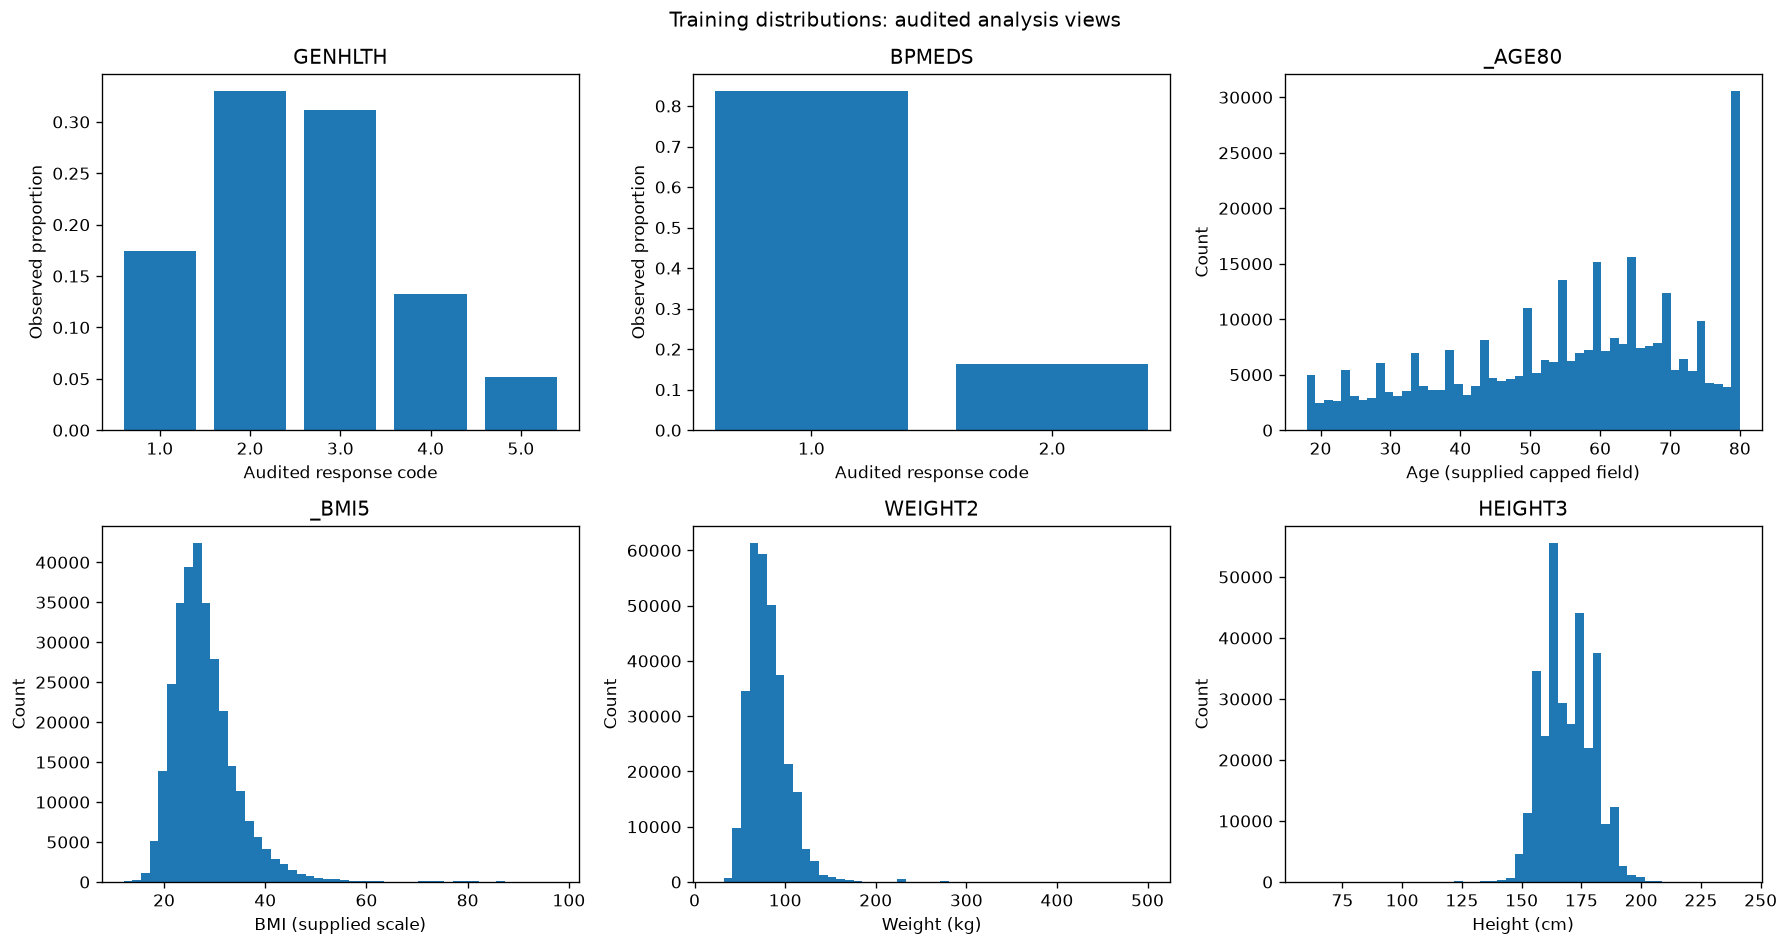

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for name, ax in zip(representative_names, axes.flat):
    observed = plot_views[name]
    values, frequencies = np.unique(observed, return_counts=True)
    if len(values) <= 10:
        ax.bar([str(v) for v in values], frequencies / len(observed))
        ax.set_ylabel("Observed proportion")
        ax.set_xlabel("Audited response code")
    else:
        ax.hist(observed, bins=50)
        ax.set_ylabel("Count")
        ax.set_xlabel({"WEIGHT2": "Weight (kg)", "HEIGHT3": "Height (cm)", "_BMI5": "BMI (supplied scale)", "_AGE80": "Age (supplied capped field)"}.get(name, "Supplied numeric value"))
    ax.set_title(name)
fig.suptitle("Training distributions: audited analysis views")
fig.tight_layout()
plt.show()


## Train/Test Observed-Value Comparisons

Column names and order must match before comparing values. For nonconstant training fields with at most 10 observed values, total variation (TV) measures differences between observed-value frequencies: 0 means identical frequencies; 1 means disjoint distributions. These fields are selected by cardinality, not assumed to be categorical. Missing values are excluded and were compared separately above. Test values absent from training are reported with their counts.

For higher-cardinality fields, we compare the 25th, 50th, and 75th percentiles. The largest absolute difference is divided by the training interquartile range (IQR). Zero-IQR fields are reported separately. An explicitly listed set of six interview-date/identifier fields is excluded from this ranking; other encoded dates, coded responses, or design fields can remain, so this is a descriptive screening measure, not a statistical significance test or proof of distribution equivalence.


Raw coded values are retained in this comparison, including special responses. Large frequency differences among sparsely observed fields can reflect small sample sizes. Quartile rankings can be distorted by encoded dates, counts, or special codes and require field-level interpretation; they are not rankings of confirmed shifts in continuous measurements.

### Feature Schema Alignment

Confirm that column names and order agree before making comparisons.

In [28]:
with open("data/dataset/x_test.csv", newline="") as f:
    test_feature_names = next(csv.reader(f))[1:]
print("Feature names and order match:", feature_names == test_feature_names)
assert feature_names == test_feature_names


Feature names and order match: True


### Low-Cardinality Frequencies and Test-Only Codes

Compare observed-value frequencies and report unseen test codes. Keep sample counts beside TV differences, especially for sparse fields.

In [29]:
low_cardinality_comparisons = []
new_test_codes = []
for j in np.where(unique_counts <= 10)[0]:
    name = feature_names[j]
    train_values = x_train[:, j][~np.isnan(x_train[:, j])]
    test_values = x_test[:, j][~np.isnan(x_test[:, j])]
    if len(train_values) == 0 or len(test_values) == 0:
        continue
    train_codes, train_counts = np.unique(train_values, return_counts=True)
    test_codes, test_counts = np.unique(test_values, return_counts=True)
    support = np.union1d(train_codes, test_codes)
    train_prob = np.zeros(len(support))
    test_prob = np.zeros(len(support))
    train_prob[np.searchsorted(support, train_codes)] = train_counts / len(train_values)
    test_prob[np.searchsorted(support, test_codes)] = test_counts / len(test_values)
    if unique_counts[j] > 1:
        low_cardinality_comparisons.append((0.5 * np.abs(train_prob - test_prob).sum(), name, len(train_values), len(test_values)))
    unseen = ~np.isin(test_codes, train_codes)
    if unseen.any():
        new_test_codes.append((name, test_codes[unseen].tolist(), test_counts[unseen].tolist()))

low_cardinality_comparisons.sort(reverse=True)
print("Nonconstant low-cardinality fields compared:", len(low_cardinality_comparisons))
print("Largest observed-frequency TV differences:")
for tv, name, train_n, test_n in low_cardinality_comparisons[:10]:
    print(f"{name}: TV={tv:.4f}, observed train={train_n}, test={test_n}")
print("Test-only values in low-cardinality training fields:", new_test_codes)


Nonconstant low-cardinality fields compared: 213
Largest observed-frequency TV differences:
LADULT: TV=0.1947, observed train=32, test=13
PCDMDECN: TV=0.1506, observed train=179, test=71
ASYMPTOM: TV=0.1110, observed train=486, test=145
ASNOSLEP: TV=0.1056, observed train=342, test=106
ASERVIST: TV=0.1030, observed train=228, test=79
ASTHMED3: TV=0.0915, observed train=485, test=144
ASINHALR: TV=0.0765, observed train=485, test=144
VINOCRE2: TV=0.0735, observed train=796, test=259
ASATTACK: TV=0.0685, observed train=490, test=148
PCPSADE1: TV=0.0497, observed train=596, test=205
Test-only values in low-cardinality training fields: [('CELLFON2', [2.0], [1]), ('VIINSUR2', [9.0], [2]), ('ASERVIST', [6.0, 7.0, 18.0], [1, 1, 1]), ('RDUCHART', [9.0], [1]), ('PCDMDECN', [13.0, 14.0], [1, 1])]


### Higher-Cardinality Quartiles

Compare quartiles relative to training IQR; retain zero-IQR cases separately. This is a screen over supplied numeric encodings, not a test of equivalence.

In [30]:
quantile_comparisons = []
zero_iqr_fields = []
excluded_date_ids = {"IDATE", "IMONTH", "IDAY", "IYEAR", "SEQNO", "_PSU"}
for j in np.where(unique_counts > 10)[0]:
    name = feature_names[j]
    if name in excluded_date_ids:
        continue
    train_values = x_train[:, j][~np.isnan(x_train[:, j])]
    test_values = x_test[:, j][~np.isnan(x_test[:, j])]
    if len(train_values) == 0 or len(test_values) == 0:
        continue
    train_q = np.quantile(train_values, [0.25, 0.5, 0.75])
    test_q = np.quantile(test_values, [0.25, 0.5, 0.75])
    iqr = train_q[2] - train_q[0]
    if iqr == 0:
        zero_iqr_fields.append(name)
    else:
        quantile_comparisons.append((np.max(np.abs(test_q - train_q)) / iqr, name, train_q, test_q))

quantile_comparisons.sort(key=lambda item: item[0], reverse=True)
print("Higher-cardinality fields compared with nonzero IQR:", len(quantile_comparisons))
print("Largest quartile differences relative to training IQR:")
for shift, name, train_q, test_q in quantile_comparisons[:10]:
    print(f"{name}: shift/IQR={shift:.4f}, train={train_q}, test={test_q}")
print("Higher-cardinality fields with zero training IQR:", zero_iqr_fields)


Higher-cardinality fields compared with nonzero IQR: 92
Largest quartile differences relative to training IQR:
FLSHTMY2: shift/IQR=0.9999, train=[102014. 102014. 112014.], test=[ 92015. 102014. 112014.]
FEETCHK2: shift/IQR=0.8779, train=[101.  101.  207.5], test=[101. 101. 301.]
PAVIG21_: shift/IQR=0.2222, train=[ 0.  0. 18.], test=[ 0.  0. 14.]
SCNTWRK1: shift/IQR=0.0833, train=[38. 40. 50.], test=[39. 40. 50.]
ASTHMAGE: shift/IQR=0.0634, train=[30. 62. 97.], test=[34.25 65.5  97.  ]
_MINAC11: shift/IQR=0.0604, train=[ 70. 140. 252.], test=[ 70. 140. 263.]
_DUALCOR: shift/IQR=0.0594, train=[0.46470523 0.66976728 0.76605211], test=[0.48259326 0.66976728 0.76605211]
PA1MIN_: shift/IQR=0.0476, train=[120. 270. 540.], test=[120. 280. 560.]
_STATE: shift/IQR=0.0400, train=[19. 29. 44.], test=[18. 29. 44.]
PAVIG11_: shift/IQR=0.0357, train=[ 0.  0. 84.], test=[ 0.  0. 87.]
Higher-cardinality fields with zero training IQR: ['NUMWOMEN', 'HHADULT', 'ADFAIL', 'ADTHINK', 'ADMOVE']


## EDA Results

Results are based on the full supplied training and test matrices. The checks above are descriptive and do not establish validation performance or causal relationships.

**Dataset and target.** The training set contains 328,135 rows and the test set 109,379 rows, with 321 aligned feature columns. The target is imbalanced: 91.17% negative and 8.83% positive. An always-negative accuracy baseline is 91.17%; positive-class F1, precision, and recall are needed when evaluating models.

**Missingness.** Approximately 44.79% of feature entries are NaN in both splits. Of 321 training features, 147 exceed 50% missingness and 99 exceed 90%. Missingness is associated with the label for selected fields, including a 37.45 percentage-point difference for BPMEDS. This motivates evaluating indicators, while retaining the distinction between structural skips and nonresponse.

**Integrity and redundancy.** All train and test Id values are unique, the splits share no Id values, and training labels align exactly by Id and order. There are no duplicate full feature rows within either split or across splits under the stated 321-feature definition. Two column pairs are exactly equal in both splits: SEQNO/_PSU and _CRACE1/_CPRACE. CTELNUM1/CELLFON2 are equal only in training; CELLFON2 has one test observation with code 2. Five fields are constant among observed values across both splits, compared with six in training alone. Constant observed values can still have informative missingness patterns.

**Field meaning and distributions.** The data mix survey responses, design variables, encoded dates, and rescaled calculated measures. Special codes and mixed-unit encodings distort raw summary statistics. The four-field code audit identifies one unexplained training WEIGHT2 value, 2099; it is flagged and excluded from the plotting view without altering the feature matrix. After documented unit decoding and nonresponse exclusion, median weight is 77.56 kg and median height is 167.64 cm. The supplied BMI median is 26.93, with a 99th percentile of 49.43 and a maximum of 97.65. Decoded weight reaches 501 kg and height ranges from 60 to 241.3 cm. These tails flag records for investigation, not automatic clipping or a conclusion that they are errors.

**Train/test comparisons.** The mean absolute feature-wise NaN-rate difference is 0.05 percentage points, with a maximum of 0.40. Observed frequencies were compared for 213 nonconstant low-cardinality fields. The largest TV difference is 0.1947 for LADULT, but it is based on only 32 observed training values and 13 test values. Five low-cardinality fields contain test-only codes: CELLFON2, VIINSUR2, ASERVIST, RDUCHART, and PCDMDECN (nine test observations in total). Quartile screening covers 92 higher-cardinality fields with nonzero training IQR; five additional eligible fields have zero IQR. Encoded fields limit interpretation of this ranking. Similar missingness does not establish identical feature distributions or absence of shift.

**Preprocessing and validation.** Evaluate imputation plus missingness indicators, removal of verified redundant columns, variable-appropriate encoding, and scaling of genuine measurements. Fit learned imputation, encoding, scaling, and feature-selection rules on training folds only; use stratified validation and inspect whether survey clusters require group separation. This full-dataset EDA is exploratory, so a final unbiased estimate requires an untouched holdout or external evaluation.

**Scope.** No model was fitted, no features were removed, and the supplied matrices were not recoded. Codebook handling covers four audited response fields and representative metadata/calculated measures, not a complete 321-field preprocessing specification. Row checks include all supplied features, and distribution comparisons are descriptive screens rather than significance tests. These boundaries are modeling decisions beyond this EDA pass.
